# Linear regression

## Importación de librerías y paquetes y definición de constantes

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Modelado
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, RidgeCV, ElasticNet
# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
from utils import get_metrics
# Warnings
import warnings


In [2]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Recopilación de datos

In [3]:
df = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/demographic_health_data.csv")
df

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,56037,43051,6104,14.178532,6326,14.694200,5359,12.448027,6577,15.277229,...,2098,8.9,8.3,9.6,2834,2.6,2.4,2.8,821,5
3136,56039,23081,2384,10.328842,2185,9.466661,2967,12.854729,4093,17.733200,...,928,7.2,6.5,8.0,1360,2.4,2.2,2.6,447,5
3137,56041,20299,3121,15.375142,3205,15.788955,2153,10.606434,2702,13.311001,...,1163,10.4,9.5,11.2,1500,3.0,2.8,3.2,430,5
3138,56043,7885,858,10.881420,1113,14.115409,715,9.067850,903,11.452124,...,506,11.3,10.3,12.1,686,3.4,3.2,3.7,207,6


## Análisis descriptivo 

In [4]:
df.shape

(3140, 108)

In [5]:
df.dtypes, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(2)
memory usage: 2.6+ MB


(fips                        int64
 TOT_POP                     int64
 0-9                         int64
 0-9 y/o % of total pop    float64
 19-Oct                      int64
                            ...   
 CKD_prevalence            float64
 CKD_Lower 95% CI          float64
 CKD_Upper 95% CI          float64
 CKD_number                  int64
 Urban_rural_code            int64
 Length: 108, dtype: object,
 None)

In [6]:
df.nunique()

fips                      3140
TOT_POP                   3074
0-9                       2723
0-9 y/o % of total pop    3136
19-Oct                    2743
                          ... 
CKD_prevalence              43
CKD_Lower 95% CI            39
CKD_Upper 95% CI            46
CKD_number                1894
Urban_rural_code             6
Length: 108, dtype: int64

## Limpieza de datos

### Eliminar duplicados:

In [7]:
df.duplicated().sum()

np.int64(0)

### Hay 1 fila duplicada, asi que nos aseguramos de no dejar duplicados en todo el dataset

In [8]:
if df.duplicated().sum():
    df = df.drop_duplicates(keep='first')
print(df.shape)
df.head()

(3140, 108)


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [9]:
df.duplicated().sum()

np.int64(0)

### Valores nulos o faltantes:

In [10]:
df.isnull().sum().sort_values(ascending=False) / len(df)

fips                      0.0
TOT_POP                   0.0
0-9                       0.0
0-9 y/o % of total pop    0.0
19-Oct                    0.0
                         ... 
CKD_prevalence            0.0
CKD_Lower 95% CI          0.0
CKD_Upper 95% CI          0.0
CKD_number                0.0
Urban_rural_code          0.0
Length: 108, dtype: float64

#### No hay valores nulos

### Limpieza de datos: Eliminar información irrelevante
    

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fips,3140.0,30401.640764,15150.559265,1001.0,18180.500000,29178.000000,45081.50000,5.604500e+04
TOT_POP,3140.0,104189.412420,333583.395432,88.0,10963.250000,25800.500000,67913.00000,1.010552e+07
0-9,3140.0,12740.302866,41807.301846,0.0,1280.500000,3057.000000,8097.00000,1.208253e+06
0-9 y/o % of total pop,3140.0,11.871051,2.124081,0.0,10.594639,11.802727,12.95184,2.546068e+01
19-Oct,3140.0,13367.976752,42284.392134,0.0,1374.500000,3274.000000,8822.25000,1.239139e+06
...,...,...,...,...,...,...,...,...
CKD_prevalence,3140.0,3.446242,0.568059,1.8,3.100000,3.400000,3.80000,6.200000e+00
CKD_Lower 95% CI,3140.0,3.207516,0.527740,1.7,2.900000,3.200000,3.50000,5.800000e+00
CKD_Upper 95% CI,3140.0,3.710478,0.613069,1.9,3.300000,3.700000,4.10000,6.600000e+00
CKD_number,3140.0,2466.234076,7730.422067,3.0,314.750000,718.000000,1776.25000,2.377660e+05


In [13]:
columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
columnas_categoricas = [col for col in columnas_categoricas if col != df.select_dtypes(include=['int64', 'float64']).columns.tolist()]
encoders = {} 
for columna in columnas_categoricas:
    le = LabelEncoder()
    df[columna] = le.fit_transform(df[columna])
    encoders[columna] = le
df

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,56037,43051,6104,14.178532,6326,14.694200,5359,12.448027,6577,15.277229,...,2098,8.9,8.3,9.6,2834,2.6,2.4,2.8,821,5
3136,56039,23081,2384,10.328842,2185,9.466661,2967,12.854729,4093,17.733200,...,928,7.2,6.5,8.0,1360,2.4,2.2,2.6,447,5
3137,56041,20299,3121,15.375142,3205,15.788955,2153,10.606434,2702,13.311001,...,1163,10.4,9.5,11.2,1500,3.0,2.8,3.2,430,5
3138,56043,7885,858,10.881420,1113,14.115409,715,9.067850,903,11.452124,...,506,11.3,10.3,12.1,686,3.4,3.2,3.7,207,6


In [14]:
corr = df.corr()['Heart disease_prevalence'].drop('Heart disease_prevalence').abs().sort_values(ascending=False)

In [22]:
corr

Heart disease_Upper 95% CI                                   0.997752
Heart disease_Lower 95% CI                                   0.997441
CKD_Upper 95% CI                                             0.908082
CKD_prevalence                                               0.892792
COPD_Upper 95% CI                                            0.890111
                                                               ...   
STATE_NAME                                                   0.008561
fips                                                         0.007443
STATE_FIPS                                                   0.007420
CNTY_FIPS                                                    0.004461
Active General Surgeons per 100000 Population 2018 (AAMC)    0.000972
Name: Heart disease_prevalence, Length: 107, dtype: float64

## Análisis de variables:

### Variables univariante: variables númericas

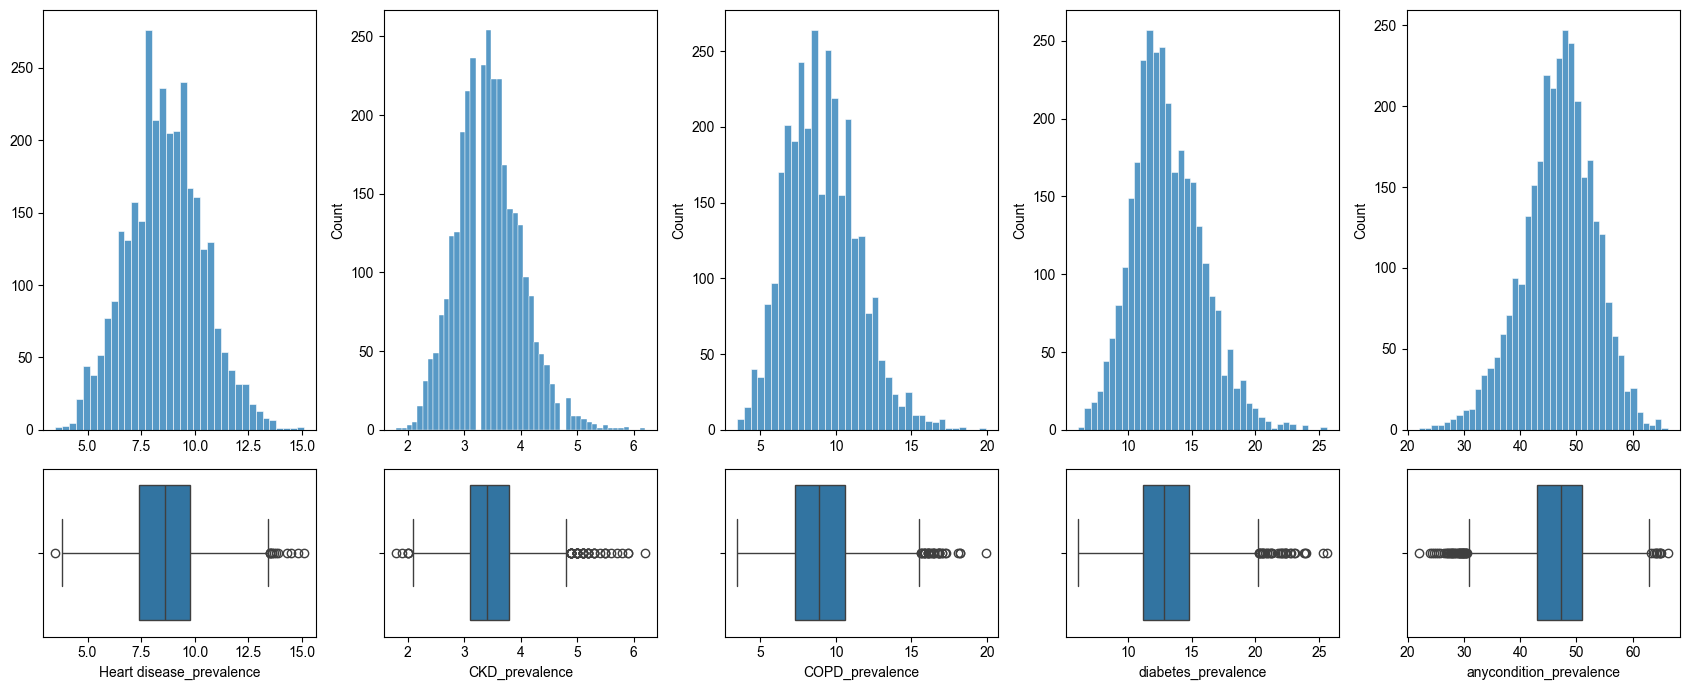

In [16]:
fig, axis = plt.subplots(2, 5, figsize=(17, 7), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="Heart disease_prevalence").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="Heart disease_prevalence")
sns.histplot(ax=axis[0, 1], data=df, x="CKD_prevalence").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="CKD_prevalence")
sns.histplot(ax=axis[0, 2], data=df, x="COPD_prevalence").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="COPD_prevalence")
sns.histplot(ax=axis[0, 3], data=df, x="diabetes_prevalence").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="diabetes_prevalence")
sns.histplot(ax=axis[0, 4], data=df, x="anycondition_prevalence").set(xlabel=None)
sns.boxplot(ax=axis[1, 4], data=df, x="anycondition_prevalence")
plt.tight_layout()
plt.show()

> #### Observaciones:
>
> - La combinación de los dos gráficos nos permite conocer las distribuciones y sus características estadísticas.
> - De la visualización resultante podemos tener claro las variables que cuentan con valores atípicos. En este caso las variables más importantes están normalizadas

### Análisis de Variables Multivariante: procedemos a buscar todas las posibles relaciones que existen entre las variables

### Observaciones:
>- Distintas correlaciones a tener en cuenta: age-charges, bmi-region/charges, charges-smoker.

Procedemos a estudiar de forma detallada las correlaciones para sacar una conclusión 

### Análisis de variables multivariante: númerico-númerico

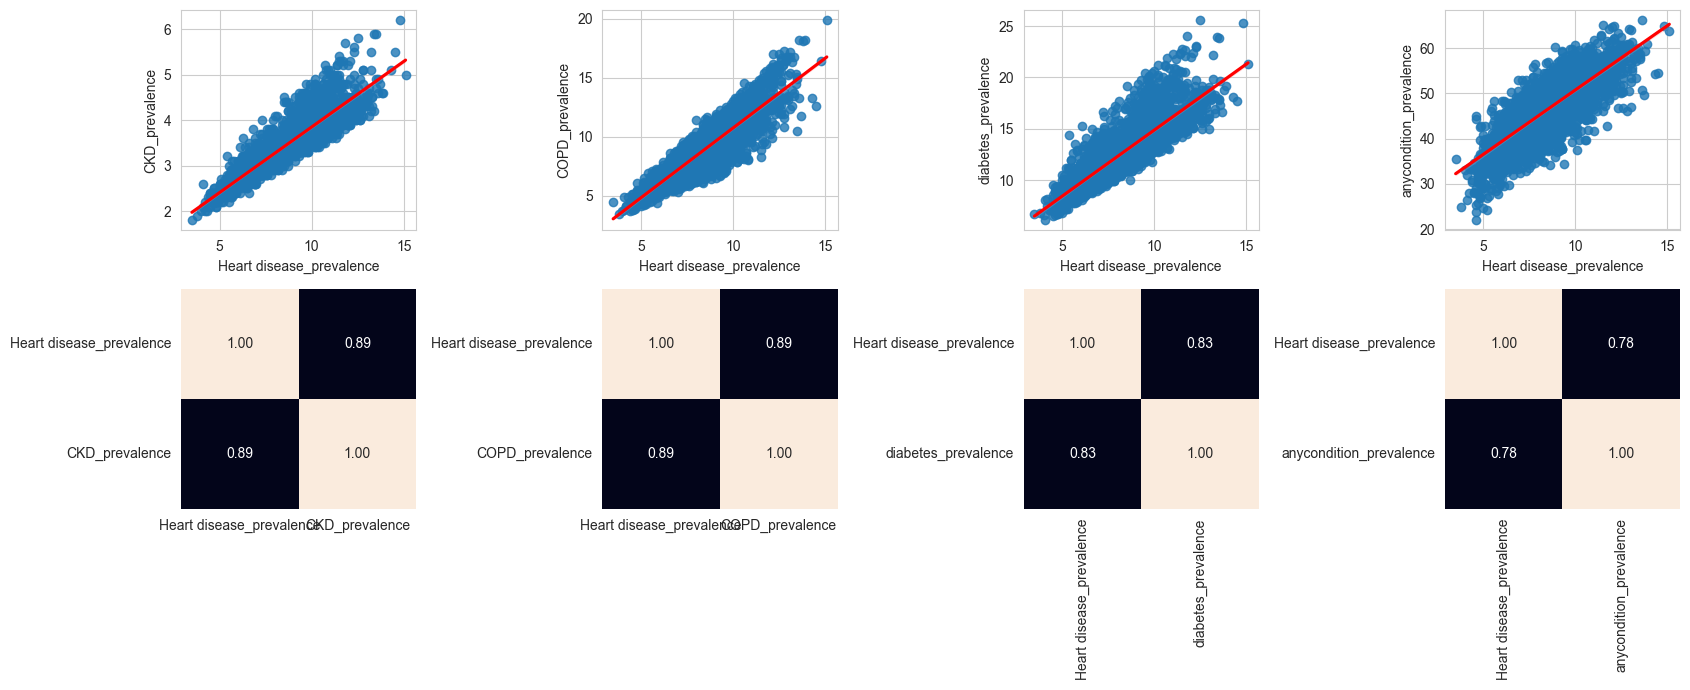

In [17]:
corr_heart_ckd = df[["Heart disease_prevalence", "CKD_prevalence"]].corr()
corr_heart_copd = df[["Heart disease_prevalence", "COPD_prevalence"]].corr()
corr_heart_diabetes = df[["Heart disease_prevalence", "diabetes_prevalence"]].corr()
corr_heart_any = df[["Heart disease_prevalence", "anycondition_prevalence"]].corr()
fig, axis = plt.subplots(2, 4, figsize=(17, 7))
sns.set_style("whitegrid")
sns.regplot(ax=axis[0,0], data=df, x="Heart disease_prevalence", y="CKD_prevalence", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,0], data=corr_heart_ckd, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,1], data=df, x="Heart disease_prevalence", y="COPD_prevalence", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,1], data=corr_heart_copd, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,2], data=df, x="Heart disease_prevalence", y="diabetes_prevalence", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,2], data=corr_heart_diabetes, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,3], data=df, x="Heart disease_prevalence", y="anycondition_prevalence", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,3], data=corr_heart_any, annot=True, fmt=".2f", cbar=False)
plt.tight_layout()
plt.show()

### Observaciones:

>- Existen muchas variables con una alta correlación y linealidad

## Ingeniería de características

### Análisis de outliers

#### Análisis descriptivo

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fips,3140.0,30401.640764,15150.559265,1001.0,18180.500000,29178.000000,45081.50000,5.604500e+04
TOT_POP,3140.0,104189.412420,333583.395432,88.0,10963.250000,25800.500000,67913.00000,1.010552e+07
0-9,3140.0,12740.302866,41807.301846,0.0,1280.500000,3057.000000,8097.00000,1.208253e+06
0-9 y/o % of total pop,3140.0,11.871051,2.124081,0.0,10.594639,11.802727,12.95184,2.546068e+01
19-Oct,3140.0,13367.976752,42284.392134,0.0,1374.500000,3274.000000,8822.25000,1.239139e+06
...,...,...,...,...,...,...,...,...
CKD_prevalence,3140.0,3.446242,0.568059,1.8,3.100000,3.400000,3.80000,6.200000e+00
CKD_Lower 95% CI,3140.0,3.207516,0.527740,1.7,2.900000,3.200000,3.50000,5.800000e+00
CKD_Upper 95% CI,3140.0,3.710478,0.613069,1.9,3.300000,3.700000,4.10000,6.600000e+00
CKD_number,3140.0,2466.234076,7730.422067,3.0,314.750000,718.000000,1776.25000,2.377660e+05


#### A priori parece que los datos están bastante normalizados, así que considero dejar los outliers y mantener los datos inmutados

### Análisis de valores faltantes

In [19]:
df.isnull().sum().sort_values(ascending=False) / len(df)

fips                      0.0
TOT_POP                   0.0
0-9                       0.0
0-9 y/o % of total pop    0.0
19-Oct                    0.0
                         ... 
CKD_prevalence            0.0
CKD_Lower 95% CI          0.0
CKD_Upper 95% CI          0.0
CKD_number                0.0
Urban_rural_code          0.0
Length: 108, dtype: float64

#### En este caso no existen valores nulos debido a la limpieza de datos que hemos hecho previamente, así como tampoco es necesario hacer inferencia de características porque no tienen ninguna relación

## Split de datos

### Dividimos el conjunto de datos en muestras de train y test

#### Elegimos la variable 'y' como target y la codificamos en valores binarios

In [21]:
X = df.drop(["Heart disease_prevalence","COUNTY_NAME", "STATE_NAME"], axis=1)
y = df['Heart disease_prevalence']
# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=24)
X_train

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
2117,39153,541918,60970,11.250780,65307,12.051085,71571,13.206980,66839,12.333785,...,37203,12.6,11.7,13.6,54137,3.1,2.9,3.4,13394,3
1452,28107,34178,4658,13.628650,4624,13.529171,4608,13.482357,4100,11.996021,...,2661,16.6,15.6,17.4,4260,3.9,3.7,4.1,997,6
2993,54007,14089,1477,10.483356,1504,10.674995,1595,11.320889,1487,10.554333,...,1748,16.8,15.5,18.2,1912,4.0,3.7,4.4,453,6
2029,38083,1349,142,10.526316,132,9.785026,99,7.338769,119,8.821349,...,108,15.2,13.9,16.5,166,4.3,4.0,4.8,48,6
3031,54083,28823,2942,10.207126,3140,10.894078,3586,12.441453,3340,11.587968,...,3298,15.7,14.5,17.0,3683,3.7,3.4,4.0,864,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2193,40129,3656,473,12.937637,525,14.359956,344,9.409190,428,11.706783,...,276,13.9,12.8,15.0,381,3.7,3.4,4.0,100,6
343,12053,190865,18108,9.487334,20457,10.718047,19544,10.239698,19494,10.213502,...,17473,14.3,13.3,15.3,22310,4.0,3.7,4.3,6178,2
2240,41069,1366,117,8.565154,118,8.638360,97,7.101025,116,8.491947,...,138,16.5,15.2,17.8,191,4.7,4.3,5.1,54,6
899,20027,7997,1032,12.904839,1004,12.554708,755,9.441040,926,11.579342,...,475,12.3,11.3,13.5,755,3.2,2.9,3.5,195,6


## Scaling & Encoding

### Scaling

#### Usamos el método  standarscaler porque los datos están suficientemente normalizados

#### Scaling X_train

In [ ]:
standard_scaler = StandardScaler()  # Instancia de: from sklearn.preprocessing import StandardScaler
columnas = X_train.columns.tolist()
num_variables = columnas
standard_train_features = standard_scaler.fit_transform(X_train[num_variables])

X_train_standard = pd.DataFrame(standard_train_features,
                               index=X_train.index,
                               columns=num_variables)
X_train_standard

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
2117,0.578536,1.193919,1.046276,-0.289035,1.116106,-0.356789,1.046528,0.304721,0.977908,0.351140,...,1.840797,-0.171996,-0.145645,-0.159052,1.370855,-0.618122,-0.590868,-0.512564,1.288339,-1.072687
1452,-0.153529,-0.208749,-0.193456,0.821067,-0.206099,0.463432,-0.197363,0.393678,-0.199077,0.150224,...,-0.202724,1.313239,1.357730,1.202115,-0.172489,0.809177,0.943252,0.643235,-0.190823,0.907658
2993,1.562974,-0.264246,-0.263487,-0.647305,-0.274080,-1.120411,-0.253332,-0.304557,-0.248097,-0.707353,...,-0.256738,1.387501,1.319182,1.488676,-0.245143,0.987589,0.943252,1.138577,-0.255731,0.907658
2029,0.507623,-0.299442,-0.292878,-0.627249,-0.303974,-1.614273,-0.281121,-1.590931,-0.273760,-1.738204,...,-0.353761,0.793407,0.702413,0.879733,-0.299170,1.522826,1.518547,1.799034,-0.304054,0.907658
3031,1.568011,-0.223543,-0.231234,-0.776262,-0.238433,-0.998837,-0.216348,0.057427,-0.213334,-0.092503,...,-0.165039,0.979061,0.933702,1.058834,-0.190343,0.452352,0.367957,0.478121,-0.206692,0.247543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2193,0.643220,-0.293068,-0.285591,0.498469,-0.295411,0.924453,-0.276570,-0.922107,-0.267963,-0.021827,...,-0.343822,0.310705,0.278384,0.342431,-0.292517,0.452352,0.367957,0.478121,-0.297849,0.907658
343,-1.217496,0.224110,0.102651,-1.112295,0.138882,-1.096520,0.080085,-0.653822,0.089715,-0.910093,...,0.673561,0.459229,0.471125,0.449891,0.386032,0.987589,0.943252,0.973463,0.427354,-1.732802
2240,0.705518,-0.299395,-0.293428,-1.542812,-0.304279,-2.250583,-0.281159,-1.667731,-0.273817,-1.934146,...,-0.351986,1.276108,1.203538,1.345396,-0.298396,2.236476,2.093842,2.294376,-0.303338,0.907658
899,-0.689025,-0.281076,-0.273284,0.483158,-0.284974,-0.077318,-0.268936,-0.911818,-0.258621,-0.097634,...,-0.332049,-0.283389,-0.299837,-0.194872,-0.280944,-0.439710,-0.590868,-0.347449,-0.286514,0.907658


#### Scaling X_test

In [ ]:
standard_test_features = standard_scaler.transform(X_test[num_variables])

X_test_standard = pd.DataFrame(standard_test_features,
                               index=X_test.index,
                               columns=num_variables)
X_test_standard

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
1190,-0.489937,0.266554,0.144084,-1.016230,0.195293,-0.842972,0.152178,-0.292332,0.184847,0.099956,...,0.370186,-1.174531,-1.186443,-1.126197,0.209255,-0.796535,-0.974399,-0.842792,0.282862,-1.072687
1445,-0.154457,-0.205232,-0.207986,-0.276543,-0.210936,-0.153658,-0.193369,0.433197,-0.200953,-0.273804,...,-0.197636,1.313239,1.357730,1.273755,-0.160143,0.630764,0.751487,0.478121,-0.182471,-1.732802
2487,1.106742,-0.175104,-0.184562,-0.443645,-0.182698,-0.223342,-0.184026,-0.250220,-0.182831,-0.613260,...,-0.071861,0.941930,0.856605,0.987194,-0.128024,0.809177,0.751487,0.973463,-0.139278,0.907658
2916,1.399475,-0.170242,-0.187908,-0.777584,-0.214923,-2.178526,-0.037203,4.920441,-0.128802,2.714031,...,-0.220236,-1.471578,-1.379184,-1.520219,-0.190219,-1.688596,-1.741459,-1.833476,-0.189988,-0.412572
1040,-0.617979,-0.250939,-0.239975,0.742957,-0.252487,0.279031,-0.240552,-0.060779,-0.237066,-0.456913,...,-0.239640,1.201847,1.126442,1.202115,-0.232457,0.630764,0.559722,0.643235,-0.245231,0.907658
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,-1.941608,-0.127162,-0.124790,0.157226,-0.139861,-0.368867,-0.139184,-0.037173,-0.144222,-0.427509,...,-0.012878,0.682014,0.663865,0.700632,-0.075761,0.452352,0.367957,0.478121,-0.091671,-1.732802
2416,1.039938,-0.285225,-0.279294,-0.085895,-0.287915,0.380389,-0.270255,-0.559663,-0.260910,0.377889,...,-0.341278,-1.026007,-1.070799,-1.018736,-0.288402,-0.618122,-0.590868,-0.512564,-0.291048,0.907658
647,-0.882413,-0.220415,-0.235726,-1.274271,-0.213180,0.919775,-0.161215,3.106265,-0.216392,-0.676673,...,-0.247094,-1.285923,-1.263539,-1.269477,-0.230229,-0.974947,-0.974399,-1.007906,-0.224351,0.247543
628,-0.884931,-0.284634,-0.281342,-0.907055,-0.292360,-1.543780,-0.270756,-0.798182,-0.263836,-1.240132,...,-0.328203,-0.320520,-0.376933,-0.266512,-0.283636,0.095527,-0.015573,0.147893,-0.286992,0.247543


### Encoding

### Guardado de scalers y encoders

In [28]:
with open('C:/Users/Simón/sayons-intro-ml-new/data/raw/demographic_health_data-standard-scaler.pkl', 'wb') as file:
    pickle.dump(standard_scaler, file)

## 4. Modelo de Regresión Lineal

In [31]:
# Modelo
lr_model = LinearRegression()

# Entrenamiento
lr_model.fit(X_train, y_train)

# Predicción
lr_y_pred_train = lr_model.predict(X_train)
lr_y_pred_test = lr_model.predict(X_test)

# Métricas
get_metrics(lr_y_pred_test, y_test, lr_y_pred_train, y_train)

,R2,MAE,MAPE,MSE,RMSE
Train set,0.999486,0.027199,0.390354,0.001557,0.039463
Test set,0.999539,0.026033,0.388083,0.001540,0.039248
Difference,0.000053,-0.001166,-0.002270,-0.000017,-0.000214


### Regularización Lasso

In [33]:
lasso_model = Lasso(alpha=0.5, max_iter=500, random_state=24)  # modelo
lasso_model.fit(X_train, y_train)  # entrenamiento

lasso_y_pred_test = lasso_model.predict(X_test)  # Predicción en test
lasso_y_pred_train = lasso_model.predict(X_train)  # Predicción en train
get_metrics(lasso_y_pred_test, y_test, lasso_y_pred_train, y_train)  # Métricas

,R2,MAE,MAPE,MSE,RMSE
Train set,0.919284,0.309397,4.533874,0.244504,0.494473
Test set,0.919264,0.301629,4.682635,0.269626,0.519255
Difference,-0.000020,-0.007768,0.148761,0.025122,0.024782


### Regularización Ridge

In [36]:
ridge_model = Ridge(alpha=0.0001,
                    max_iter=5000,
                    random_state=24).fit(X_train, y_train)
ridge_y_pred_test = ridge_model.predict(X_test)  # Predicción en test
ridge_y_pred_train = ridge_model.predict(X_train)  # Predicción en test

get_metrics(ridge_y_pred_test, y_test, ridge_y_pred_train, y_train)  # Métricas

,R2,MAE,MAPE,MSE,RMSE
Train set,0.999486,0.027199,0.390354,0.001557,0.039463
Test set,0.999539,0.026033,0.388083,0.001540,0.039248
Difference,0.000053,-0.001166,-0.002270,-0.000017,-0.000214


### LassoCV

In [37]:
lasso_cv_model = (LassoCV(alphas=np.logspace(-6, 6, 10),
                         cv=5,
                         random_state=24,
                         n_jobs=-1).fit(X_train, y_train))

lasso_cv_y_pred_test = lasso_cv_model.predict(X_test)  # Predicción en test
lasso_cv_y_pred_train = lasso_cv_model.predict(X_train)  # Predicción en train
get_metrics(lasso_cv_y_pred_test, y_test, lasso_cv_y_pred_train, y_train)  # Métricas

,R2,MAE,MAPE,MSE,RMSE
Train set,0.999403,0.029055,0.420553,0.001810,0.042539
Test set,0.999472,0.027931,0.412448,0.001764,0.042002
Difference,0.000069,-0.001124,-0.008105,-0.000045,-0.000537


## RidgeCV

In [38]:
ridge_cv_model = RidgeCV(alphas=np.logspace(-6, 6, 10),
                         cv=5).fit(X_train, y_train)

ridge_cv_y_pred_test = ridge_cv_model.predict(X_test)  # Predicción en test
ridge_cv_y_pred_train = ridge_cv_model.predict(X_train)  # Predicción en train
get_metrics(ridge_cv_y_pred_test, y_test, ridge_cv_y_pred_train, y_train)

C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\_lib\_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=3.82763e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\_lib\_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=7.77359e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\_lib\_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=4.04913e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\

,R2,MAE,MAPE,MSE,RMSE
Train set,0.999486,0.027194,0.390367,0.001557,0.039463
Test set,0.999539,0.026037,0.388074,0.001540,0.039247
Difference,0.000053,-0.001157,-0.002293,-0.000017,-0.000216


## ElasticNet

In [39]:
elasticnet_model = ElasticNet(alpha=0.0001, max_iter=400, random_state=18).fit(X_train, y_train)

elasticnet_y_pred_test = elasticnet_model.predict(X_test)
elasticnet_y_pred_train = elasticnet_model.predict(X_train)
get_metrics(elasticnet_y_pred_test, y_test, elasticnet_y_pred_train, y_train)

,R2,MAE,MAPE,MSE,RMSE
Train set,0.999299,0.031594,0.451409,0.002124,0.046086
Test set,0.999345,0.030925,0.449288,0.002186,0.046753
Difference,0.000047,-0.000669,-0.002122,0.000062,0.000668


#### Guardamos el modelo utilizado

In [ ]:
with open('C:/Users/Simón/sayons-intro-ml-new/models/modelo-regresión-lineal.pkl', 'wb') as file3:
    pickle.dump(model, file3)